In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the data
df=pd.read_csv('youtube_data.csv')

In [3]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [4]:
df.tail()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811
122399,vid_1056,2024-06-25 10:50:40.993199,9931,770.0,NaN,38466.837135,27.305703,517587,Tech,TV,CA,253.842824


In [5]:
df.shape

(122400, 12)

In [6]:
#To know missing values and the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [7]:
print(df['device'].unique())

['TV' 'Tablet' 'Mobile' 'Desktop']


In [8]:
print(df['country'].unique())

['IN' 'CA' 'UK' 'US' 'DE' 'AU']


In [9]:
# Convert the 'date' column from object to datetime
df['date'] = pd.to_datetime(df['date'])

In [10]:
#check for null values
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(2400)

In [12]:
#Remove duplicates
df=df.drop_duplicates()

In [13]:

df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,120000,120000.000000,114000.000000,114000.000000,114000.000000,120000.000000,120000.000000,120000.000000
mean,2024-12-08 03:24:11.233198848,9999.832333,1099.585044,274.349842,37540.749921,16.017910,502291.970050,252.711361
min,2024-06-09 10:50:40.993199,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,2024-09-07 10:50:40.993199104,9933.000000,650.000000,162.000000,26364.159667,9.005928,252641.500000,199.892158
50%,2024-12-08 10:50:40.993199104,10000.000000,1102.000000,274.000000,37522.221205,16.009269,503633.500000,252.678607
75%,2025-03-09 10:50:40.993199104,10067.000000,1547.250000,387.000000,48782.739997,23.026064,752386.250000,305.613497
max,2025-06-08 10:50:40.993199,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254
std,NaN,99.918405,519.526733,129.746796,12987.818758,8.084928,288364.967705,61.954125


In [15]:
# 2. Handle Missing Values
# We'll fill missing numbers with the 'median' (the middle value)
df['views'] = df['views'].fillna(df['views'].median())
df['likes'] = df['likes'].fillna(df['likes'].median())
df['comments'] = df['comments'].fillna(df['comments'].median())
df['subscribers'] = df['subscribers'].fillna(df['subscribers'].median())
df['watch_time_minutes'] = df['watch_time_minutes'].fillna(df['watch_time_minutes'].median())
df['ad_revenue_usd'] = df['ad_revenue_usd'].fillna(df['ad_revenue_usd'].median())

# For 'category' or 'country' (text), we fill with the 'mode' (most frequent word)
df['category'] = df['category'].fillna(df['category'].mode()[0])
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['device'] = df['device'].fillna(df['device'].mode()[0])


In [16]:
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

                                         UNIVARIATE ANALYSIS

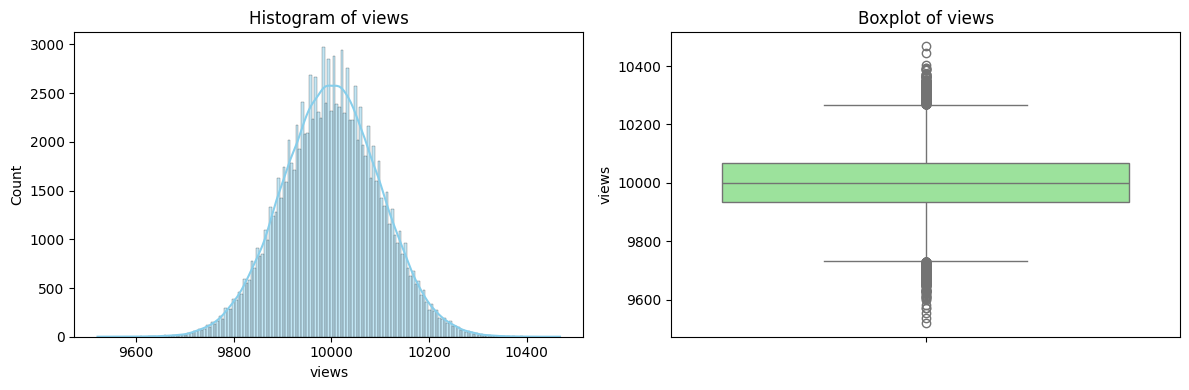

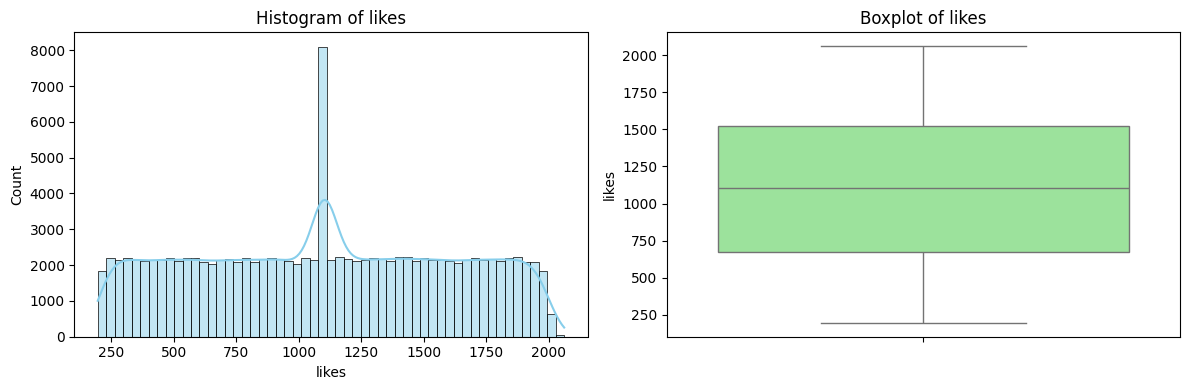

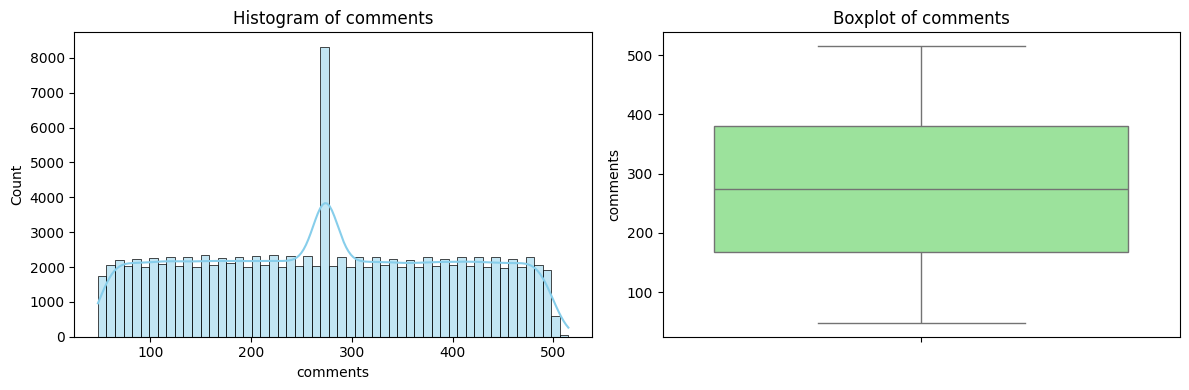

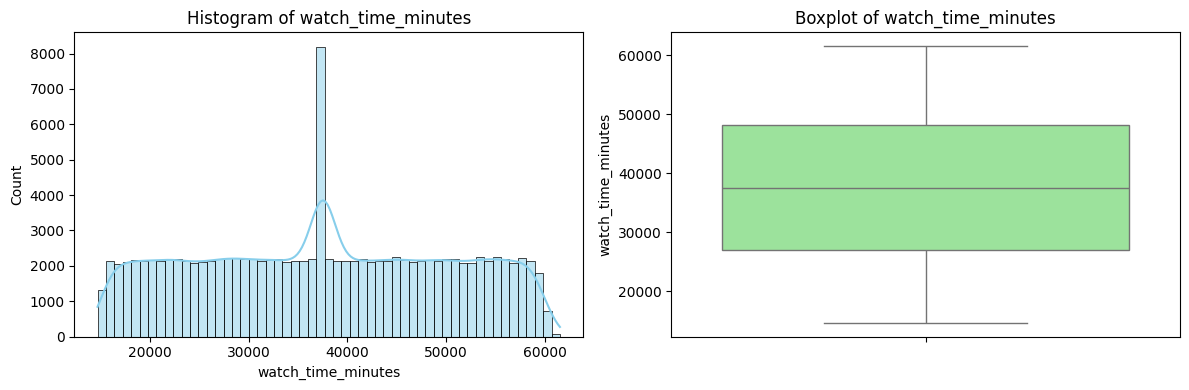

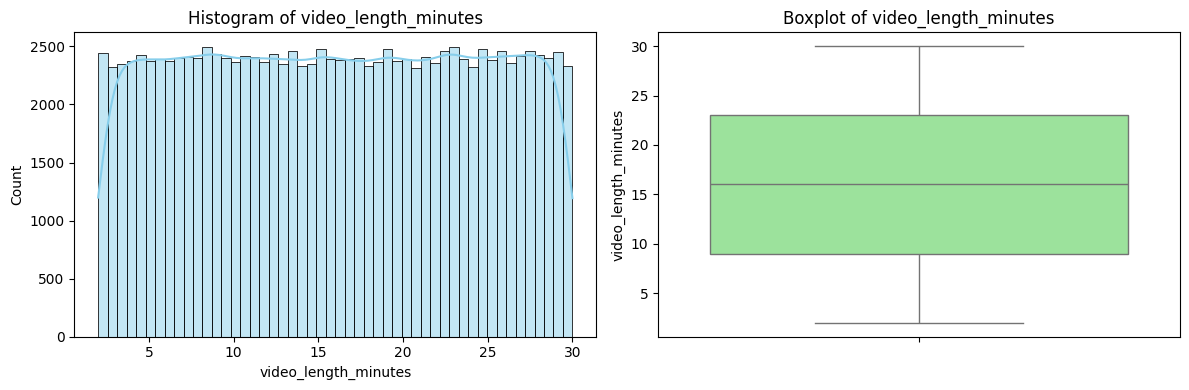

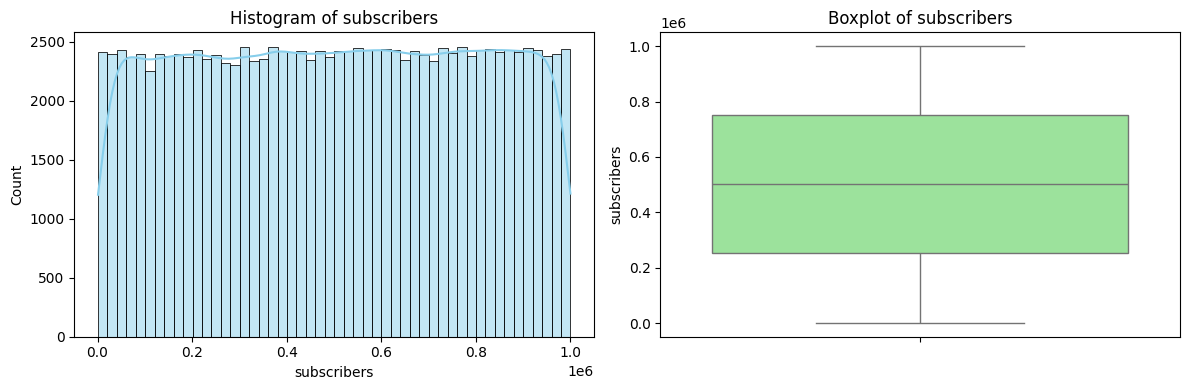

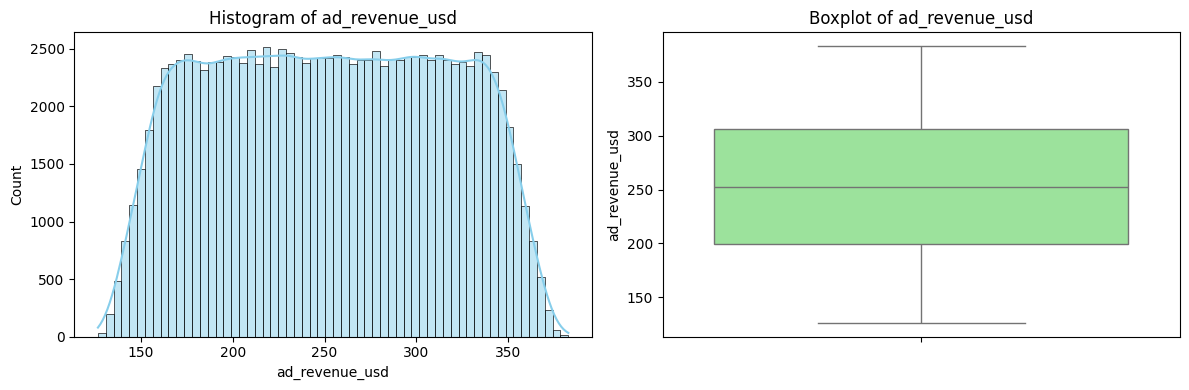

In [17]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Loop through and create a Histogram + Boxplot for each
for col in numeric_cols:
    plt.figure(figsize=(12, 4))

    # Left side: Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Histogram of {col}')

    # Right side: Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

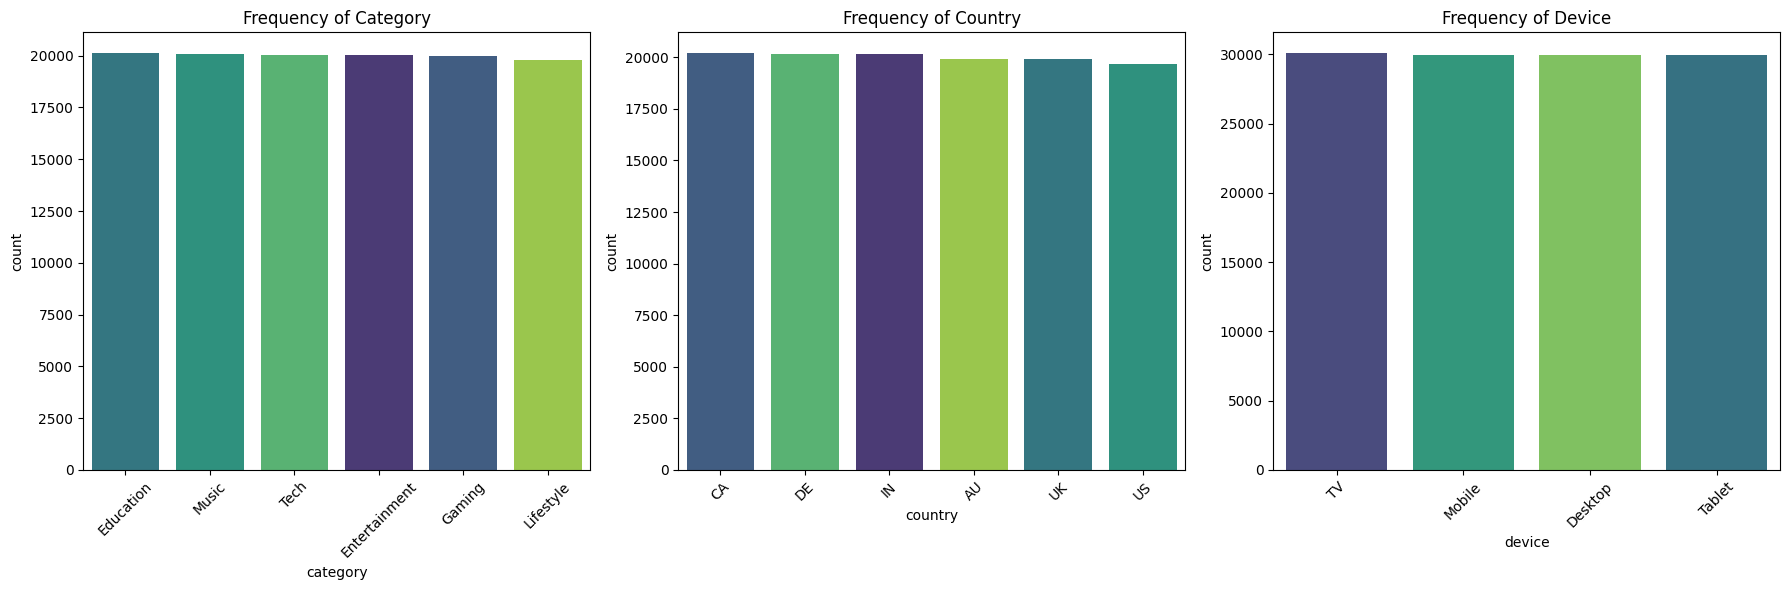

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the categorical columns
cat_cols = ['category', 'country', 'device']

# 2. Create the plots in a single row (1 row, 3 columns)
plt.figure(figsize=(18, 6))

for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i+1) # Changed to 1 row, 3 cols

    # Added hue and legend=False to stop the red warnings
    sns.countplot(data=df, x=col, hue=col, palette='viridis',
                  legend=False, order=df[col].value_counts().index)

    plt.title(f'Frequency of {col.capitalize()}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

                                BIVARIATE ANALYSIS

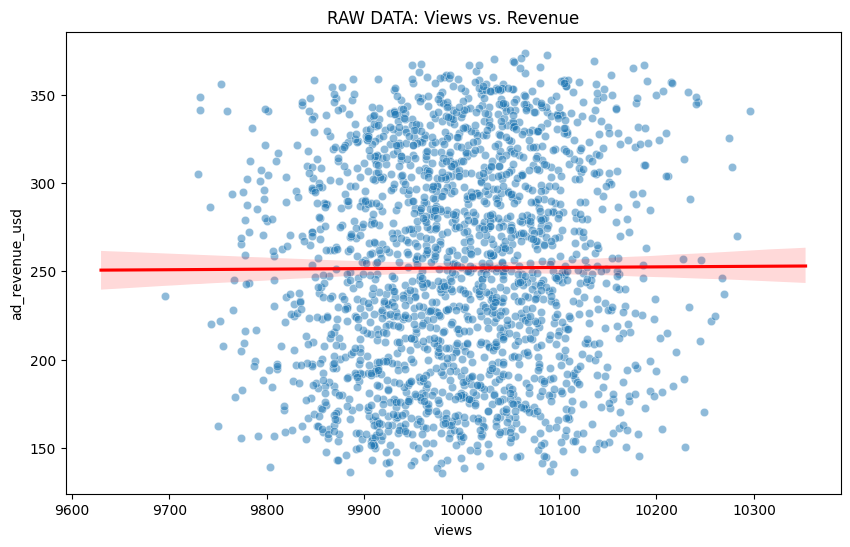

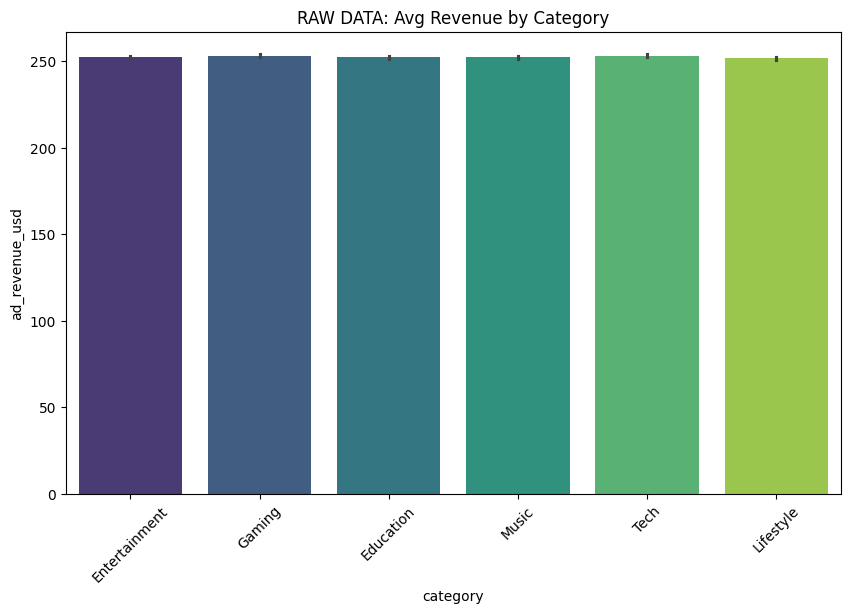

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
# --- 1. Bivariate (Raw Relationship) ---
# Does more views = more money in the raw data?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='views', y='ad_revenue_usd', alpha=0.5)
sns.regplot(data=df.sample(2000), x='views', y='ad_revenue_usd', scatter=False, color='red')
plt.title('RAW DATA: Views vs. Revenue')
plt.show()

# --- 3. Categorical (Raw Comparison) ---
# Which original category makes the most?
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='category', y='ad_revenue_usd', palette='viridis', hue='category', legend=False)
plt.title('RAW DATA: Avg Revenue by Category')
plt.xticks(rotation=45)
plt.show()

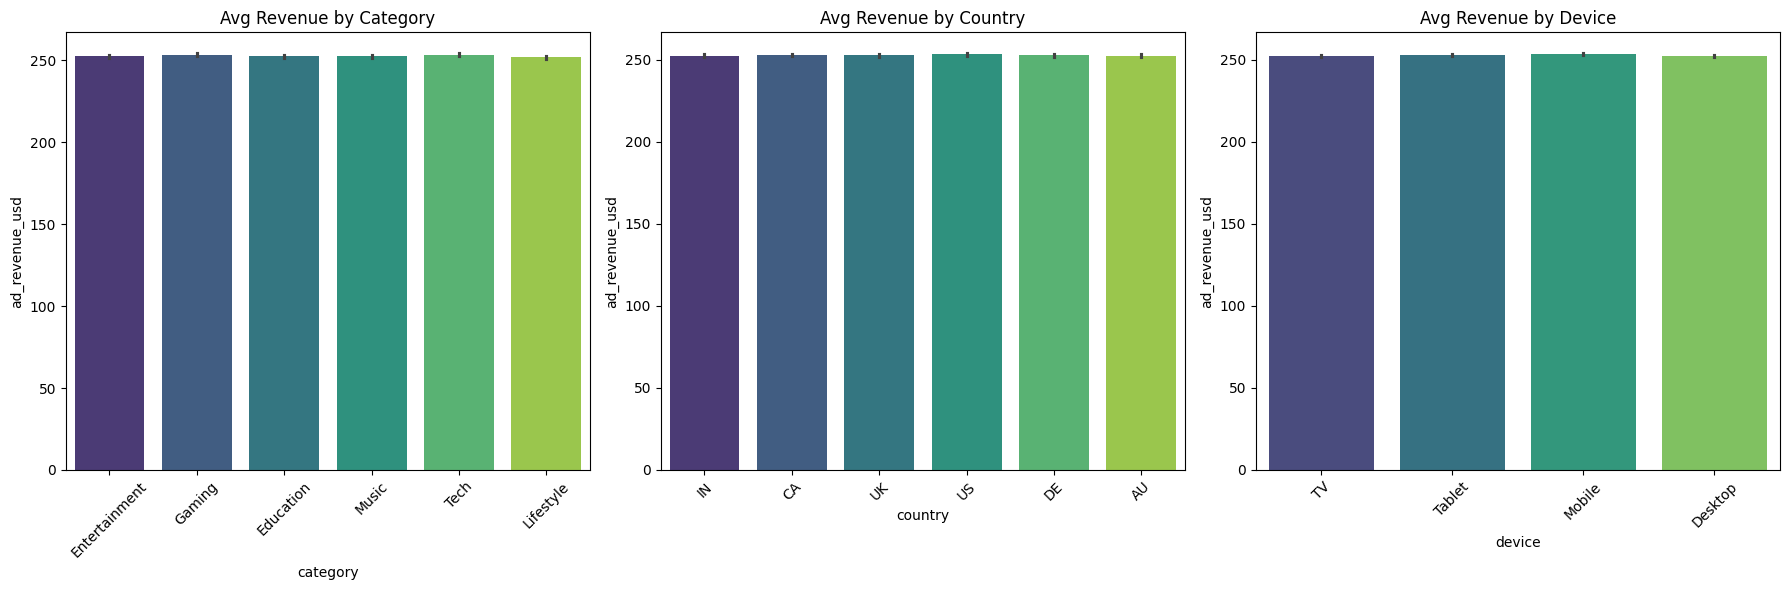

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['category', 'country', 'device']

plt.figure(figsize=(18,6))

for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)

    sns.barplot(data=df, x=col, y='ad_revenue_usd',
                palette='viridis', hue=col, legend=False)

    plt.title(f'Avg Revenue by {col.capitalize()}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

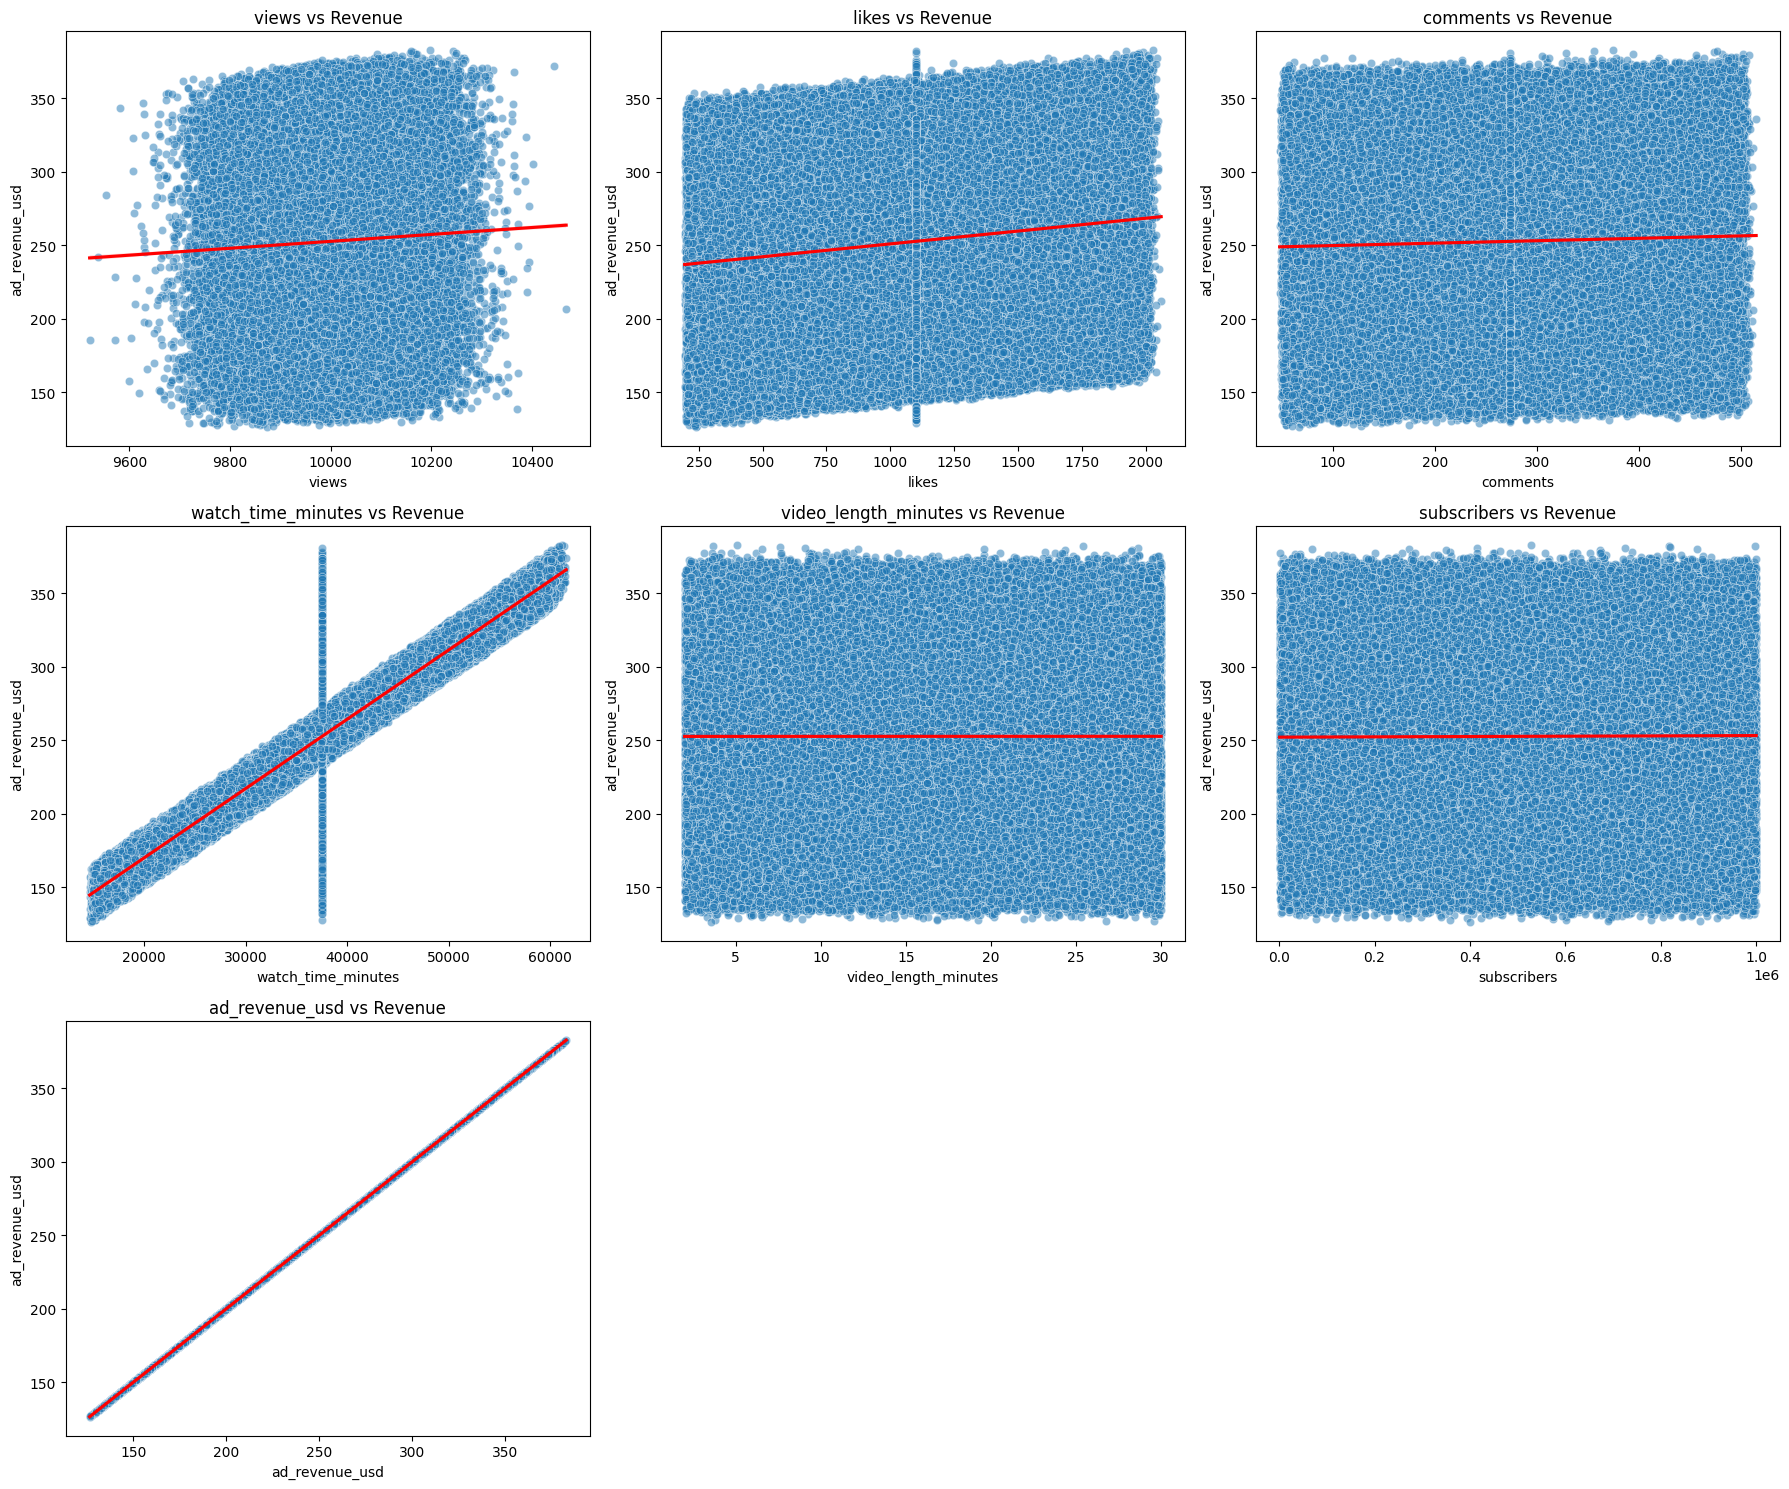

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
num_cols = df.select_dtypes(include=['number']).columns

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5*n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)

    sns.scatterplot(data=df, x=col, y='ad_revenue_usd', alpha=0.5)
    sns.regplot(data=df, x=col, y='ad_revenue_usd', scatter=False, color='red')

    plt.title(f'{col} vs Revenue')

plt.tight_layout()
plt.show()


In [22]:
# Feature Engineering (Creating New "Clues")
# 1. Engagement Rate: How 'viral' or interactive is the video?
# We add 1 to the denominator to avoid 'Division by Zero' errors if views are 0.
df['engagement_rate'] = (df['likes'] + df['comments']) / (df['views'] + 1)

# 2. Average View Duration: How many minutes does a typical viewer stay?
df['avg_view_duration'] = df['watch_time_minutes'] / (df['views'] + 1)

# 3. Time-Based Features
# Extract the Month
df['month'] = df['date'].dt.month

print("Feature Engineering Complete!")
display(df[['engagement_rate', 'avg_view_duration', 'month']].head())


Feature Engineering Complete!


,engagement_rate,avg_view_duration,month
0,0.155077,2.666520,9
1,0.098622,1.518242,9
2,0.214498,5.677625,11
3,0.142800,3.122523,1
4,0.236097,1.583991,4


In [23]:
# 1. Retention Rate: What percentage of the video did the average person watch?
# We multiply views by length to get 'Total Potential Watch Time'
df['retention_rate'] = df['watch_time_minutes'] / (df['views'] * df['video_length_minutes'] + 1)

# 2. Viral Factor: Are views coming from more than just subscribers?
df['view_to_sub_ratio'] = df['views'] / (df['subscribers'] + 1)

# 3. Comment Intensity: Out of people who liked, how many actually commented?
df['comment_to_like_ratio'] = df['comments'] / (df['likes'] + 1)

# 4. Weekend Flag: Does the date fall on a Saturday (5) or Sunday (6)?
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

print("All advanced features created!")
display(df[['retention_rate', 'view_to_sub_ratio', 'is_weekend']].head())

All advanced features created!


,retention_rate,view_to_sub_ratio,is_weekend
0,0.931715,0.043562,0
1,0.063964,0.013610,1
2,0.216719,0.041977,0
3,0.265312,0.023094,0
4,0.238722,0.235279,0


In [24]:
#Video Performance Score
df['performance_score'] = (
    df['views'] * 0.5 +
    df['likes'] * 0.3 +
    df['comments'] * 0.2
)

In [25]:
# We multiply watch time by views to get a 'Total Attention' metric
df['total_attention'] = df['views'] * df['watch_time_minutes']

# Likes * Watch Time (High quality engagement)
df['quality_engagement'] = df['likes'] * df['watch_time_minutes']

print("Interaction Features Added!")

Interaction Features Added!


In [26]:
print(df['category'].unique())
print("---------------  --------------------")
print(df['category'].value_counts())

['Entertainment' 'Gaming' 'Education' 'Music' 'Tech' 'Lifestyle']
---------------  --------------------
category
Education        20123
Music            20065
Tech             20028
Entertainment    20025
Gaming           19974
Lifestyle        19785
Name: count, dtype: int64


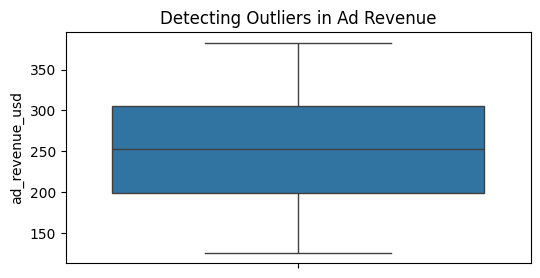

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualising outliers for your target variable
plt.figure(figsize=(6, 3))
sns.boxplot(y=df['ad_revenue_usd'])
plt.title('Detecting Outliers in Ad Revenue')
plt.show()

In [28]:
# List only the continuous numeric columns
cols_to_check = ['views', 'likes', 'comments', 'watch_time_minutes', 'ad_revenue_usd']

for col in cols_to_check:
  # 2. Calculate the 25th (Q1) and 75th (Q3) percentiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
  # 3. Calculate the distance between them (IQR)
    IQR = Q3 - Q1
  # 4. Define the "Fences" (Lower and Upper bounds)
  # Anything beyond these is considered an outlier
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

  # 5. "Capping": Replace values outside limits with the limit itself
  # Values lower than 'lower_limit' become 'lower_limit'
  # Values higher than 'upper_limit' become 'upper_limit'
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("Outliers capped successfully!")

Outliers capped successfully!


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [32]:
import pandas as pd

# Make sure you load your data first
X = pd.read_csv('youtube_data.csv')

# Then your code will work
Num_Disc = X.select_dtypes(include=['int64']).columns


In [33]:
# Drop the high-cardinality ID/Date AND the features with no relationship
cols_to_drop = [
    'ad_revenue_usd', 
    'video_id', 'date',          # Memory hogs
    'views', 'likes', 'comments', # Flat relationships
    'video_length_minutes', 
    'subscribers'
]

X = df.drop(cols_to_drop, axis=1)
y = df['ad_revenue_usd']

In [34]:
Num_Disc = X.select_dtypes(include=['int64']).columns
Num_Cont = X.select_dtypes(include=['float64']).columns
Cat_data = X.select_dtypes(include=['object']).columns

In [35]:
# 1. Identify which columns are Discrete, Continuous, or Categorical
# Make sure X is your dataframe containing features (without 'ad_revenue_usd')
Num_Disc = X.select_dtypes(include=['int64']).columns
Num_Cont = X.select_dtypes(include=['float64']).columns
Cat_data = X.select_dtypes(include=['object']).columns

# 2. Define the individual Transformers
Num_Disc_Transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', RobustScaler())
])

Num_Cont_Transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

Cat_Transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# 3. Combine them into the Preprocess_Step
Preprocess_Step = ColumnTransformer(transformers=[
    ('Num_Disc', Num_Disc_Transformer, Num_Disc),
    ('Num_Cont', Num_Cont_Transformer, Num_Cont),
    ('Cat', Cat_Transformer, Cat_data)
])

print(" Preprocessing Pipeline and Column Names defined successfully!")

 Preprocessing Pipeline and Column Names defined successfully!


In [36]:
Preprocess_Step

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num_Disc', ...), ('Num_Cont', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [ ]:
print(df.columns.tolist())

['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd', 'engagement_rate', 'avg_view_duration', 'month', 'retention_rate', 'view_to_sub_ratio', 'comment_to_like_ratio', 'is_weekend', 'performance_score', 'total_attention', 'quality_engagement']


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor,  HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import train_test_split


# Create the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Preprocess_Step you defined earlier
X_train_pre = Preprocess_Step.fit_transform(X_train)
X_test_pre = Preprocess_Step.transform(X_test)

# 1. Define the 5 models to test
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, verbose=1, random_state=42),
    "XGBoost": XGBRegressor(n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(n_estimators=50),
    "Hist Gradient Boosting": HistGradientBoostingRegressor()
}

# 2. Loop to train and evaluate each one
model_performance = []

for name, model_obj in models.items():
    print(f"Training {name}...") # This helps to see progress!
    model_obj.fit(X_train_pre, y_train)
    y_pred = model_obj.predict(X_test_pre)


# Calculate Metrics (The ones required by your project)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    model_performance.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2)
    })

# 3. Show the Results Table
results_df = pd.DataFrame(model_performance).sort_values(by="R2 Score", ascending=False)
print(" Model Competition Results ")
display(results_df)

Training Linear Regression...
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   45.9s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   60.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:    0.1s finished


Training XGBoost...
Training AdaBoost...
Training Hist Gradient Boosting...
 Model Competition Results 


,Model,R2 Score,MAE ($),RMSE ($)
0,Linear Regression,0.9526,3.13,13.48
1,Random Forest,0.9513,3.69,13.66
4,Hist Gradient Boosting,0.9513,3.76,13.65
2,XGBoost,0.9465,4.34,14.31
3,AdaBoost,0.9285,10.22,16.55


In [48]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn import set_config

# 1. Use 'preprocessor' from your %who list
# 2. DELETE the 'to_dense' line entirely to save 3.6GB of RAM
final_pipeline = Pipeline(steps=[
    ('preprocessor', Preprocess_Step), 
    ('regressor', LinearRegression())
])

# 3. Enable the visual diagram
set_config(display='diagram')

# 4. Fit the whole thing on your original X_train
final_pipeline.fit(X_train, y_train)

# 5. Show the diagram
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num_Disc', ...), ('Num_Cont', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [49]:
import pickle

# This checks if the names exist in your memory right now
try:
    # 1. Save the model
    with open('best_model.pkl', 'wb') as f:
        pickle.dump(models['Linear Regression'], f)
    
    # 2. Save the preprocessor
    with open('preprocessor.pkl', 'wb') as f:
        pickle.dump(Preprocess_Step, f)
        
    print("✅ Success! 'best_model.pkl' and 'preprocessor.pkl' are created.")
except KeyError:
    print("❌ Error: Check the name in your 'models' dictionary. Is there a space?")
except NameError:
    print("❌ Error: 'Preprocess_Step' is not defined. Run the preprocessing cell again.")

✅ Success! 'best_model.pkl' and 'preprocessor.pkl' are created.


In [ ]:
%who

FunctionTransformer	 HistGradientBoostingRegressor	 Pipeline	 best_model	 f	 loaded_model	 loaded_preprocessor	 model	 pd	 
pickle	 preprocessor	 set_config	 


In [46]:
print(models.keys())

dict_keys(['Linear Regression', 'Random Forest', 'XGBoost', 'AdaBoost', 'Hist Gradient Boosting'])
